In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
from PIL import Image
import torch
from torchvision import transforms
import matplotlib.pyplot as plt

In [3]:
wa_path = "/data6/rajivporana_scratch/nih_data/test_images/whatsapp_compressed_test/images"
og_path = "/data6/rajivporana_scratch/nih_data/test_images/nih_test/images"

In [4]:
def load_images_from_folder(folder_path):
    images = []
    for filename in os.listdir(folder_path):
        if filename.endswith(('.png', '.jpg', '.jpeg')):  # Add other image formats if needed
            img_path = os.path.join(folder_path, filename)
            image = Image.open(img_path).convert('RGB')  # Convert to RGB
            images.append(image)
    return images

In [5]:
wa_images = load_images_from_folder(wa_path)
og_images = load_images_from_folder(og_path)

In [6]:
#convert wa_images to tensor
wa_tensor = []
for img in wa_images:
    img = transforms.ToTensor()(img)
    wa_tensor.append(img)

In [ ]:
og_tensor = []
for img in og_images:
    img = transforms.ToTensor()(img)
    og_tensor.append(img)

In [8]:
wa_tensor[0].shape

torch.Size([3, 1024, 1024])

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '5'

In [30]:
import os
import torch

# Directory containing the heatmap tensors
wa_dir = 'heatmaps/Pne_Nor_Cov_baseline-lr:0.001-wd:0.0_balmy-wildflower-378/whatsapp/'
og_dir = 'heatmaps/Pne_Nor_Cov_baseline-lr:0.001-wd:0.0_balmy-wildflower-378/original/'
# List all files in the directory
wa_files = [f for f in os.listdir(wa_dir) if f.endswith('.pt')]
og_files = [f for f in os.listdir(og_dir) if f.endswith('.pt')]
# Load each tensor and combine them into a single tensor
wa = []
og = []
for file in wa_files:
    tensor = torch.load(os.path.join(wa_dir, file))
    wa.append(tensor)
for file in og_files:
    tensor = torch.load(os.path.join(og_dir, file))
    og.append(tensor)
# Stack the tensors along a new dimension to create a single tensor
wa_tensor = torch.stack(wa)
og_tensor = torch.stack(og)


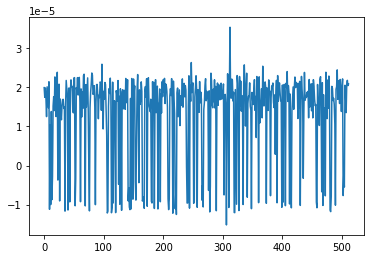

In [42]:
plt.plot(wa_tensor[26].cpu().numpy())

plt.show()

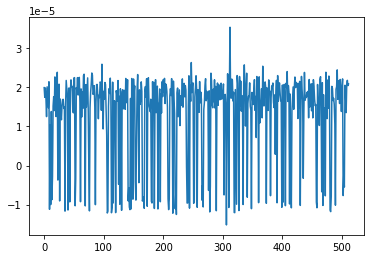

In [43]:
plt.plot(og_tensor[26].cpu().numpy())
plt.show()

In [29]:
import matplotlib.pyplot as plt
import cv2

In [16]:
a = torch.load("heatmaps/grad_norm_sq/Pne_Nor_Cov_baseline-lr:0.001-wd:0.0_balmy-wildflower-378/original/0a6c60063b4bae4de001caaba306d1_jumbo.pt_alpha_14.pt")
b = torch.load("heatmaps/grad_norm_sq/Pne_Nor_Cov_baseline-lr:0.001-wd:0.0_balmy-wildflower-378/whatsapp/0a6c60063b4bae4de001caaba306d1_jumbo.pt_alpha_14.pt")

In [62]:


# Directory containing the heatmap tensors
og_act_dir = 'heatmaps/temp/Pne_Nor_Cov_baseline-lr:0.001-wd:0.0_balmy-wildflower-378/original/'
wa_act_dir = 'heatmaps/temp/Pne_Nor_Cov_baseline-lr:0.001-wd:0.0_balmy-wildflower-378/whatsapp/'
# List all files in the directory that contain 'activations' in their name
wa_activation_files = [f for f in os.listdir(wa_act_dir) if 'activations' in f and f.endswith('.pt')]
og_activation_files = [f for f in os.listdir(og_act_dir) if 'activations' in f and f.endswith('.pt')]
# Load each tensor and store them in a list
wa_activation_tensors = []
og_activation_tensors = []
for file in wa_activation_files:
    tensor = torch.load(os.path.join(wa_act_dir, file))
    wa_activation_tensors.append(tensor)
for file in og_activation_files:
    tensor = torch.load(os.path.join(og_act_dir, file))
    og_activation_tensors.append(tensor)
# Optionally, stack the tensors along a new dimension to create a single tensor
wa_acts = torch.stack(wa_activation_tensors)
og_acts = torch.stack(og_activation_tensors)

print(f"Loaded {len(wa_activation_tensors)} tensors from {og_act_dir}")

Loaded 164 tensors from heatmaps/temp/Pne_Nor_Cov_baseline-lr:0.001-wd:0.0_balmy-wildflower-378/original/


In [65]:


# Directory containing the heatmap tensors
og_grad_dir = 'heatmaps/temp/Pne_Nor_Cov_baseline-lr:0.001-wd:0.0_balmy-wildflower-378/original/'
wa_grad_dir = 'heatmaps/temp/Pne_Nor_Cov_baseline-lr:0.001-wd:0.0_balmy-wildflower-378/whatsapp/'
# List all files in the directory that contain 'activations' in their name
wa_gradient_files = [f for f in os.listdir(wa_grad_dir) if 'heatmap' in f and f.endswith('.pt')]
og_gradient_files = [f for f in os.listdir(og_grad_dir) if 'heatmap' in f and f.endswith('.pt')]
# Load each tensor and store them in a list
wa_gradient_tensors = []
og_gradient_tensors = []
for file in wa_gradient_files:
    tensor = torch.load(os.path.join(wa_grad_dir, file))
    wa_gradient_tensors.append(tensor)
for file in og_gradient_files:
    tensor = torch.load(os.path.join(og_grad_dir, file))
    og_gradient_tensors.append(tensor)
# Optionally, stack the tensors along a new dimension to create a single tensor
wa_grads= torch.stack(wa_gradient_tensors)
og_grads = torch.stack(og_gradient_tensors)

print(f"Loaded {len(wa_gradient_tensors)} tensors from {og_grad_dir}")

RuntimeError: PytorchStreamReader failed reading zip archive: failed finding central directory

In [69]:
wa_acts.squeeze(1).shape

torch.Size([164, 512, 64, 64])

In [70]:
og_acts.squeeze(1).shape

torch.Size([164, 1, 512, 64, 64])

In [68]:
vals = [55, 61, 69, 76, 85, 94, 106, 108, 123, 126, 129, 131, 147]

In [5]:
wa_heatmaps = "heatmaps/grad_cam/Pne_Nor_Cov_baseline-lr:0.001-wd:0.0_good-wind-7/whatsapp/"
og_heatmaps = "heatmaps/grad_cam/Pne_Nor_Cov_baseline-lr:0.001-wd:0.0_good-wind-7/original/"
# List all files in the directory
wa_files = [f for f in os.listdir(wa_heatmaps) if f.endswith('.pt')]
og_files = [f for f in os.listdir(og_heatmaps) if f.endswith('.pt')]
# Load each tensor and combine them into a single tensor
wa = []
og = []
for file in wa_files:
    tensor = torch.load(os.path.join(wa_heatmaps, file))
    wa.append(tensor)
for file in og_files:
    tensor = torch.load(os.path.join(og_heatmaps, file))
    og.append(tensor)

# Stack the tensors along a new dimension to create a single tensor
wa_heatmap_tensor = torch.stack(wa)
og_heatmap_tensor = torch.stack(og)


In [47]:
re_wa = wa_heatmap_tensor.view(4812, 64 * 64)
res_og = og_heatmap_tensor.view(4812, 64 * 64)

In [50]:
cosine_similarity = nn.CosineSimilarity(dim=1, eps=1e-6)
cos = cosine_similarity(re_wa, res_og)
cos

tensor([0.9334, 0.9866, 0.9889,  ..., 0.9871, 0.0438, 0.9912], device='cuda:0')

In [51]:
cos.shape

torch.Size([4812])

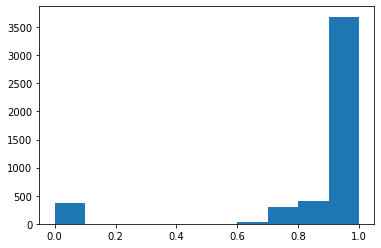

In [52]:
#torch.histc(cos, bins=10, min=0, max=1)
plt.hist(cos.detach().cpu().numpy(), bins=10, range=(0, 1))
plt.show()

In [53]:
#get the indices of the those whose cosine similarity is less than 0.4 and more than 0.1
indices = torch.where((cos < 0.1))
#intersection between the indices
intersection = set(indices[0].tolist())
intersection

{55,
 61,
 69,
 76,
 85,
 94,
 106,
 108,
 123,
 126,
 129,
 131,
 147,
 171,
 174,
 242,
 244,
 258,
 285,
 299,
 303,
 311,
 321,
 342,
 344,
 349,
 354,
 386,
 416,
 440,
 445,
 447,
 463,
 466,
 474,
 481,
 484,
 489,
 495,
 504,
 508,
 510,
 512,
 526,
 534,
 573,
 574,
 601,
 617,
 634,
 642,
 673,
 679,
 681,
 682,
 704,
 723,
 749,
 756,
 770,
 773,
 802,
 810,
 813,
 818,
 842,
 847,
 858,
 873,
 884,
 889,
 903,
 910,
 932,
 942,
 947,
 970,
 975,
 990,
 1002,
 1010,
 1016,
 1021,
 1041,
 1042,
 1048,
 1065,
 1080,
 1081,
 1086,
 1101,
 1108,
 1119,
 1122,
 1133,
 1137,
 1150,
 1178,
 1218,
 1227,
 1252,
 1261,
 1271,
 1280,
 1286,
 1309,
 1313,
 1327,
 1331,
 1348,
 1360,
 1375,
 1382,
 1389,
 1396,
 1411,
 1414,
 1440,
 1454,
 1455,
 1473,
 1488,
 1493,
 1522,
 1524,
 1540,
 1569,
 1584,
 1587,
 1591,
 1598,
 1658,
 1699,
 1704,
 1715,
 1720,
 1742,
 1751,
 1756,
 1770,
 1783,
 1793,
 1794,
 1800,
 1844,
 1855,
 1856,
 1869,
 1874,
 1881,
 1887,
 1906,
 1914,
 1942,
 1950,


In [54]:
intersection = list(intersection)
len(intersection)

372

In [67]:
#get vals from intersection which are less than 164
vals = [i for i in intersection if i < 164]
vals

[55, 61, 69, 76, 85, 94, 106, 108, 123, 126, 129, 131, 147]

In [6]:
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

torch.Size([64])

In [57]:
t = []
for i in intersection:
    t.append({wa_files[i],cos[i].item()})

In [61]:
import pandas as pd
df = pd.DataFrame(t, columns=['cos sim', 'image_id'])

# Save the DataFrame to a CSV file
csv_file_path = 'img_list.csv'
df.to_csv(csv_file_path, index=False)

print(f"CSV file saved to {csv_file_path}")

CSV file saved to img_list.csv


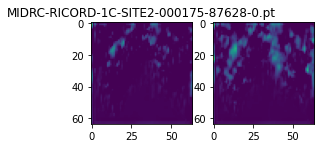

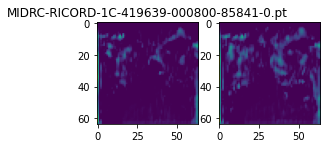

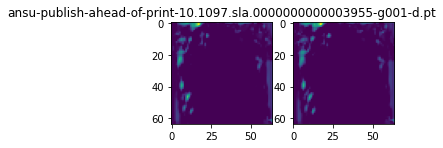

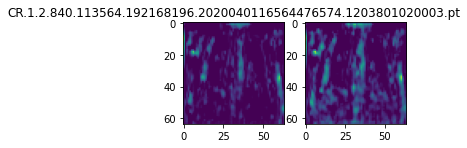

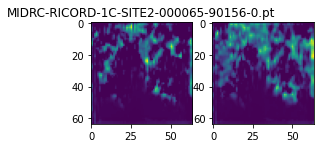

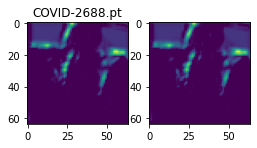

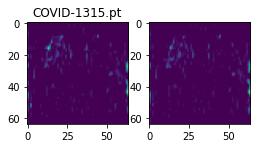

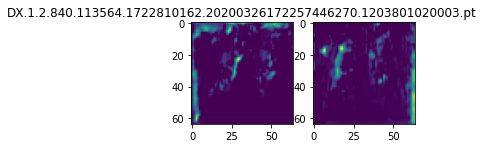

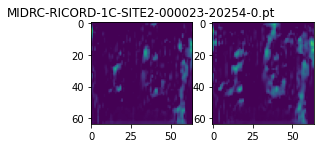

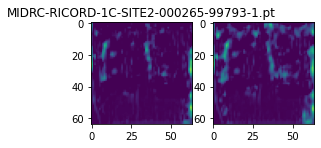

In [29]:
for i in range(len(intersection)):
    fig = plt.figure(figsize=(4, 3))
  
# setting values to rows and column variables
    rows = 1
    columns = 2
    #convert tensor to img
    Image1 = transforms.ToPILImage()(wa_heatmap_tensor[intersection[i]])
    Image2 = transforms.ToPILImage()(og_heatmap_tensor[intersection[i]])
    # Adds a subplot at the 1st position
    fig.add_subplot(rows, columns, 1)
    
    # showing image
    plt.imshow(Image1)
    plt.title(wa_files[intersection[i]])
    
    # Adds a subplot at the 2nd position
    fig.add_subplot(rows, columns, 2)
    
    # showing image
    plt.imshow(Image2)

In [ ]:
import argparse
import torch
import json
import numpy as np
import supervised_experiments.model_selector as model_selector
from supervised_experiments.utils import create_logger
import supervised_experiments.datasets as datasets
from tqdm import tqdm


def load_saved_model(models, tasks, net_basename, folder="saved_models/", name="best"):
    state = torch.load(f"{folder}{net_basename}_{name}_model.pkl")
    models['rep'].load_state_dict(state["model_rep"])
    for t in tasks:
        models[t].load_state_dict(state[f"model_{t}"])

def convert_label_toints(labels):
    nih_classes = [ 'Ate', 'Car', 'Eff', 'Inf', 'Mas', 'Nod', 'Pne',
                        'Pnt', 'Con', 'Ede', 'Emp', 'Fib', 'Ple', 
                        'Her', 'Nor', 'Cov']    
    #                 0    1     2     3     4      5      6    7     8     9      10     11    12    13    14
    chex_classes = ["Nor","EnC","Car","LunO","LunL","Ede","Con","Pne","Ate","Pnt","Ple","PleO","Fra","Sup","Cov"]            
    int_labels = []                        
    for x in labels:
        int_labels.append(nih_classes.index(x))
    return int_labels 

In [ ]:
model = model_selector.get_model(args.dataset, configs[args.dataset]['tasks'], device=DEVICE)
    
load_saved_model(model, tasks, args.net_basename, folder=configs["utils"]["model_storage"], name=args.model_type)

test_loader = datasets.get_dataset(args.dataset, args.batch_size, configs,
                                    generator=g, worker_init_fn=seed_worker, train=False,
                                    partial_dataset=args.partial_dataset, nih_labels=nih_labels,
                                    whatsapp_data = True, image_name = True,
                                    covid_img_only = True)  

In [ ]:
def create_heatmap(model, val_rep, t):
    out_t, _, _ = model[t](val_rep, None)
    if out_t[0][1] > out_t[0][0]:
        out_t[0][1].backward(retain_graph=True)
    else:
        out_t[0][0].backward(retain_graph=True)
    gradients = model[t].get_activations_gradient()
    activations = model[t].get_activations(val_rep).detach()
    pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])
    for i in range(activations.shape[1]):
        activations[:, i, :, :] *= pooled_gradients[i]
    heatmap = torch.mean(activations, dim=1).squeeze()
    heatmap = torch.nn.functional.relu(heatmap)
    heatmap /= torch.max(heatmap)
    return heatmap
    